Dataset creado: 10000 filas, 18 columnas (16 features + 2 targets)
Porcentaje de defaults: 19.58%
Porcentaje de claims: 31.70%

=== Descripción estadística general ===
                 age  gender         income  debt_to_income_ratio  \
count   10000.000000   10000   10000.000000          10000.000000   
unique           NaN       2            NaN                   NaN   
top              NaN  Female            NaN                   NaN   
freq             NaN    5002            NaN                   NaN   
mean       46.166100     NaN   60039.011900              0.352185   
std        16.421738     NaN   19563.395922              0.144136   
min        18.000000     NaN   20000.000000              0.100000   
25%        32.000000     NaN   46338.750000              0.230000   
50%        46.000000     NaN   59764.500000              0.350000   
75%        61.000000     NaN   73380.000000              0.480000   
max        74.000000     NaN  128372.000000              0.600000   

   

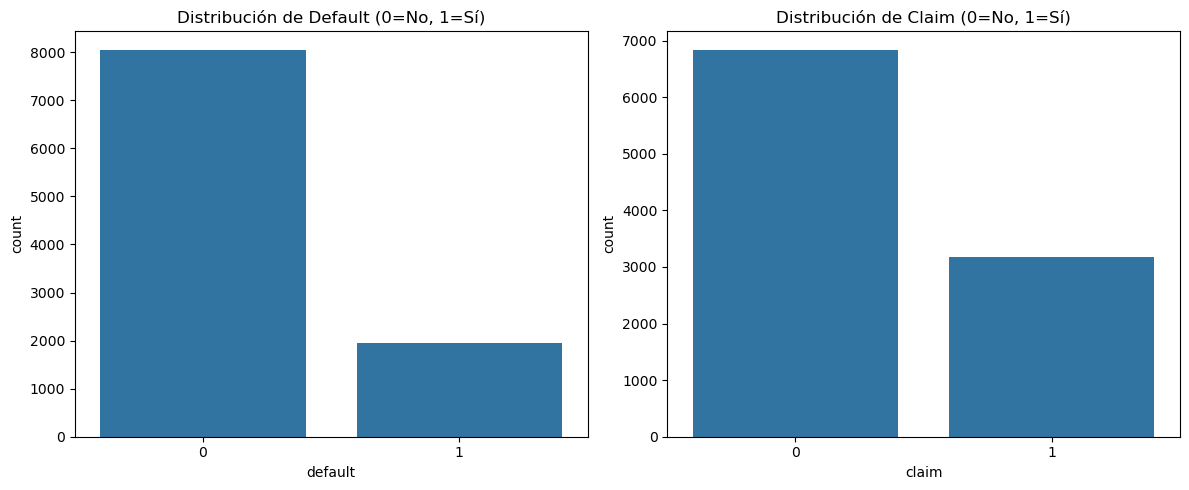

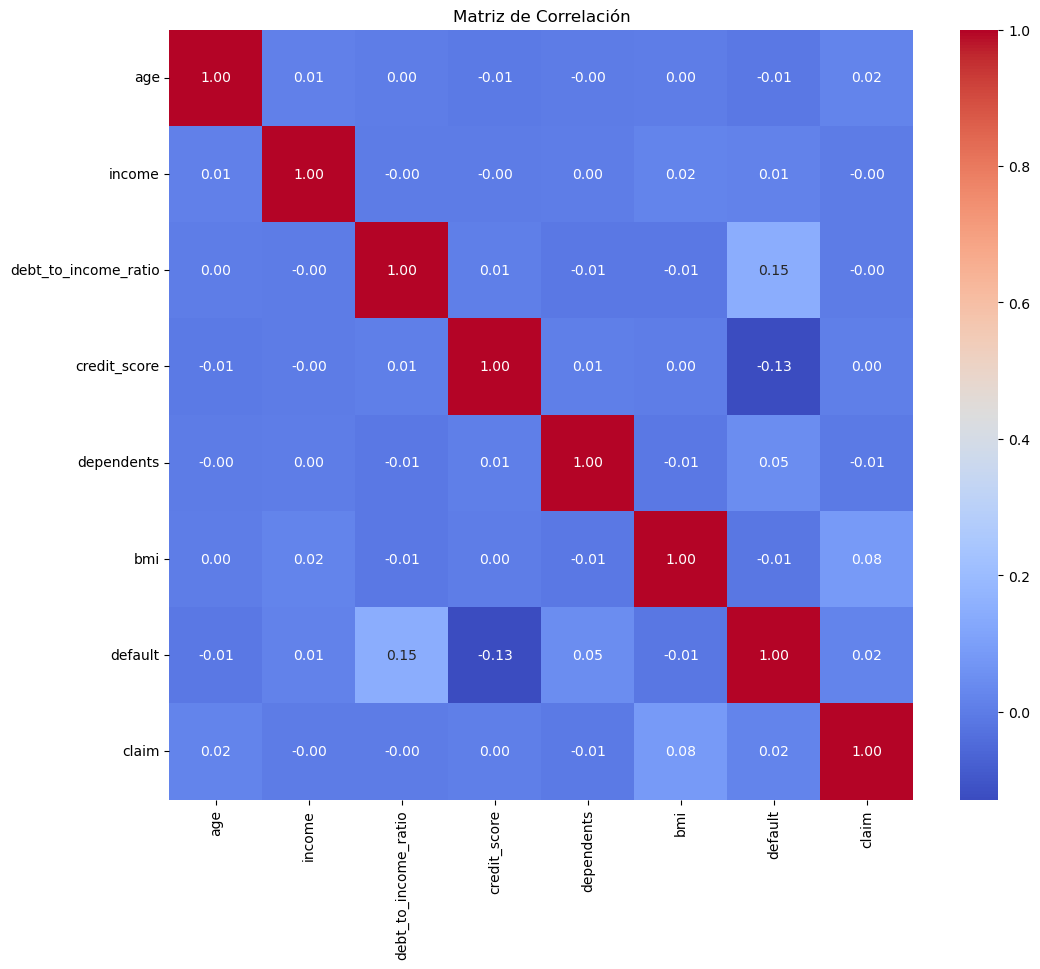

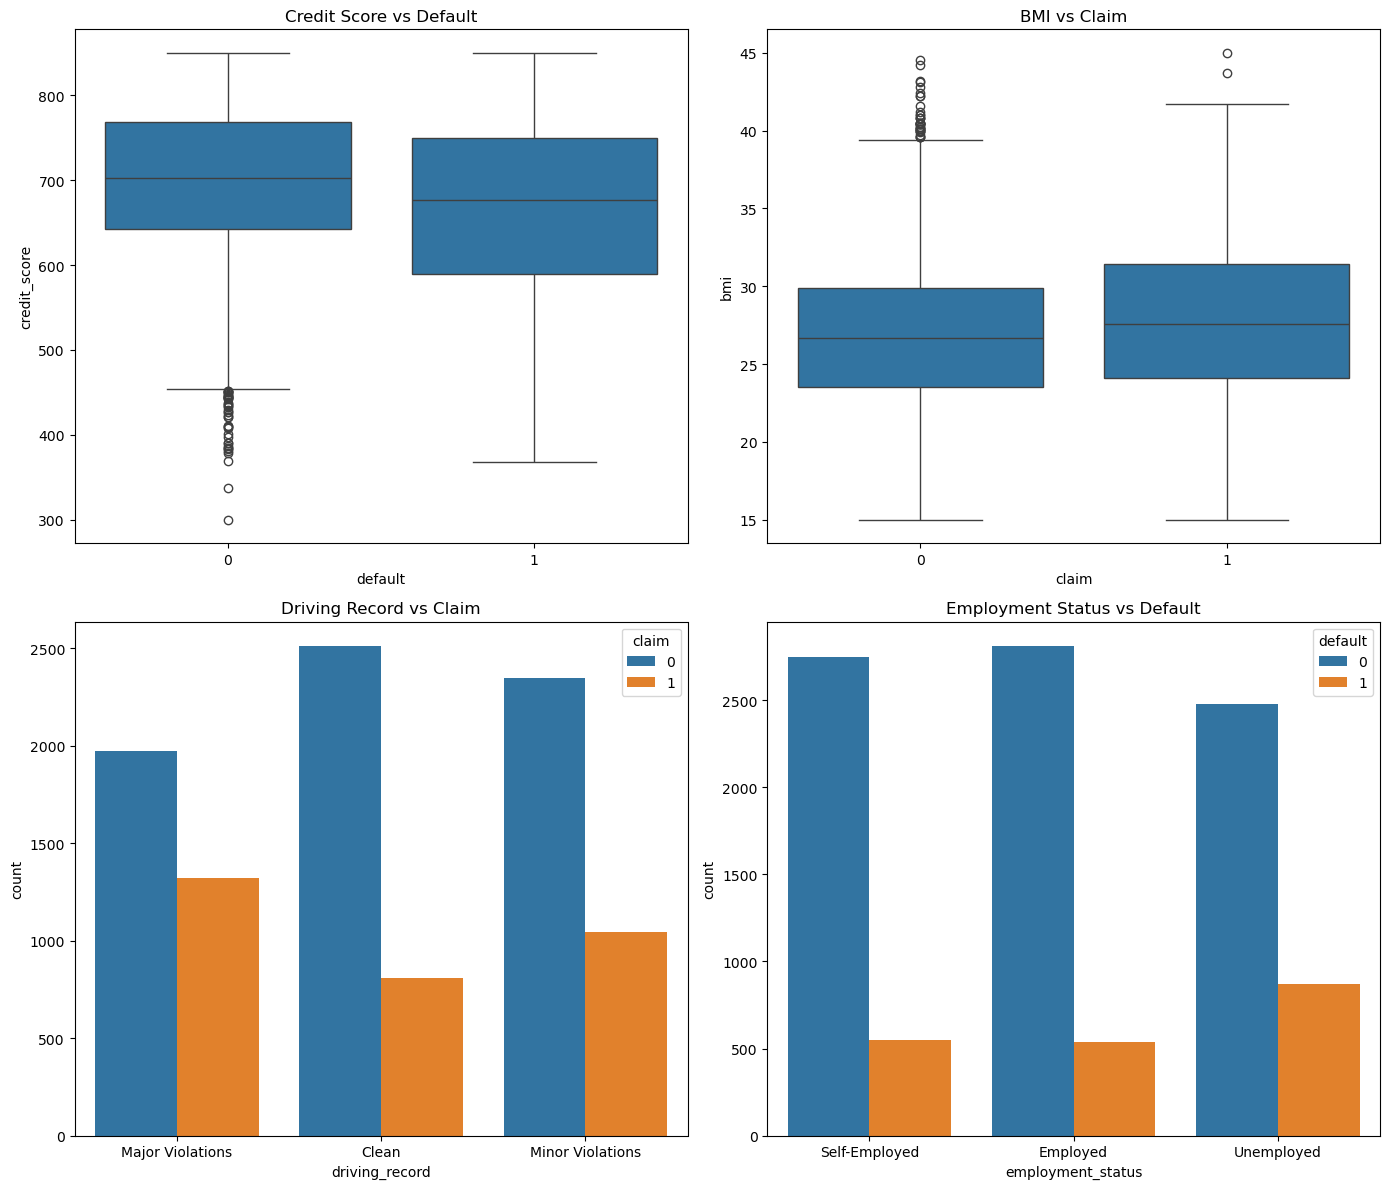


=== Ejemplos de análisis de riesgo (primeros 10 casos) ===
      actual_default  actual_claim  prob_default  prob_claim  prob_integrated  \
6252               0             0      0.177551    0.408056         0.292804   
4684               1             0      0.263971    0.134929         0.199450   
1731               0             0      0.250392    0.241694         0.246043   
4742               0             0      0.092326    0.376309         0.234318   
4521               0             0      0.005356    0.267922         0.136639   
6340               0             1      0.106958    0.190166         0.148562   
576                0             0      0.011584    0.345590         0.178587   
5202               0             0      0.176805    0.331340         0.254072   
6363               1             0      0.142352    0.651365         0.396858   
439                0             1      0.223146    0.307464         0.265305   

     risk_level  
6252       Bajo  
4684       B

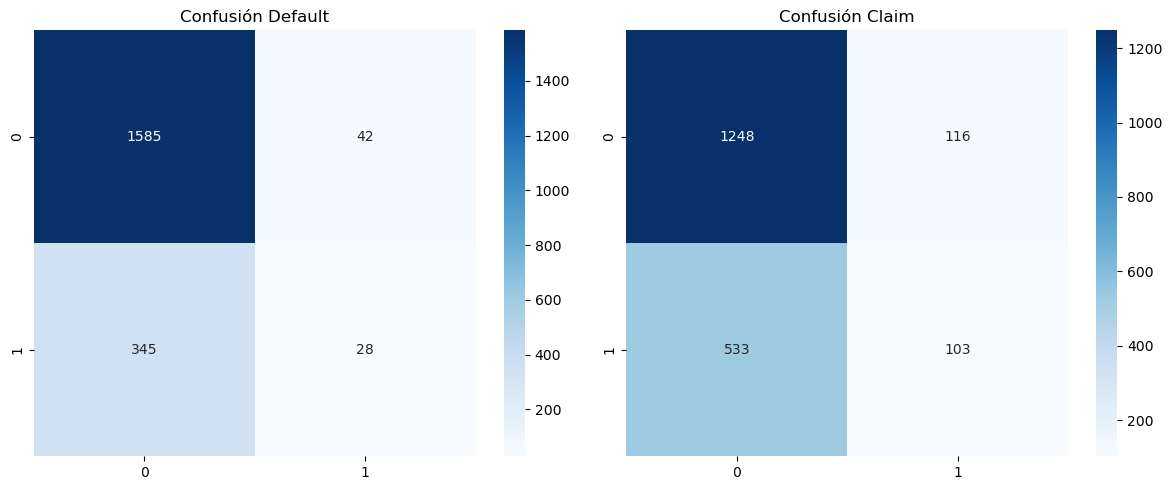

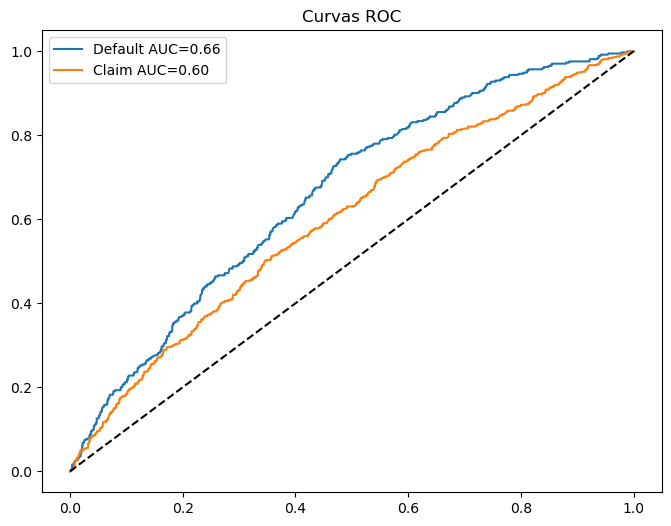

100%|██████████| 100/100 [01:31<00:00,  1.09it/s]


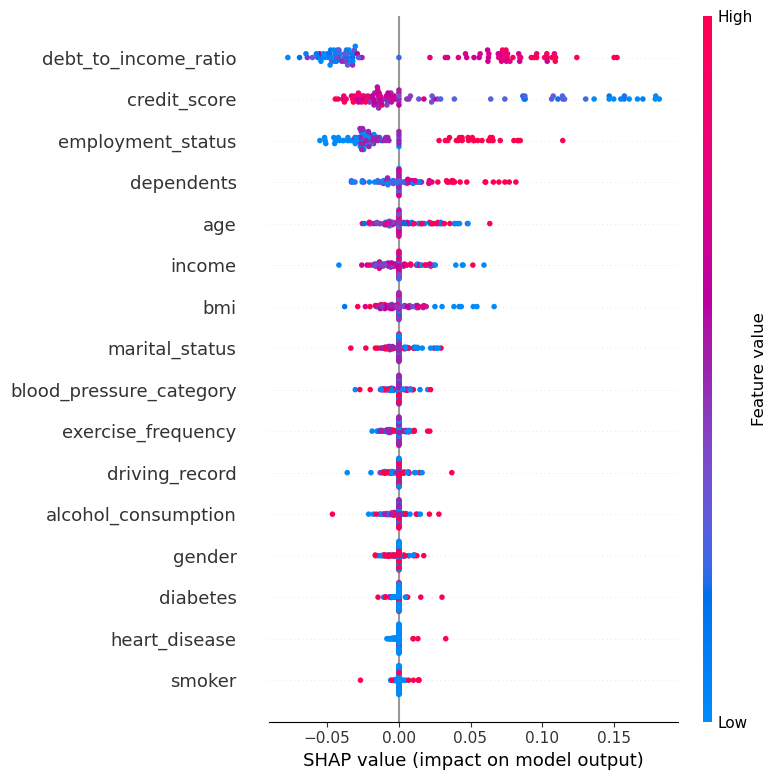

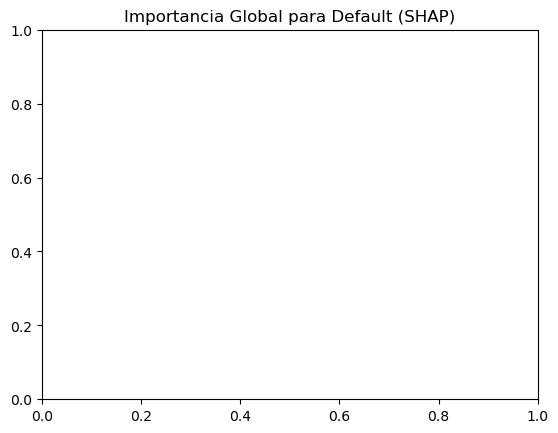

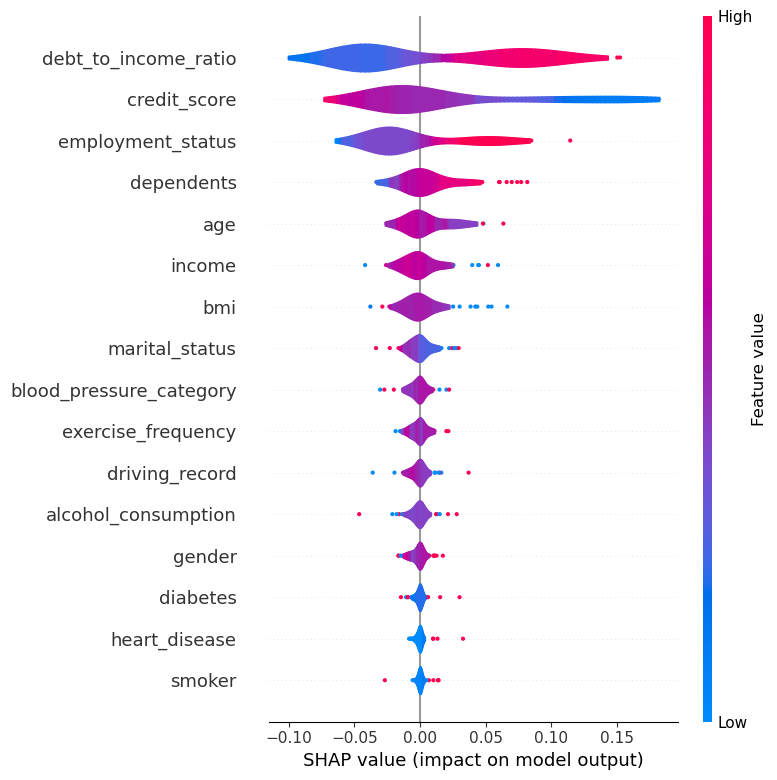

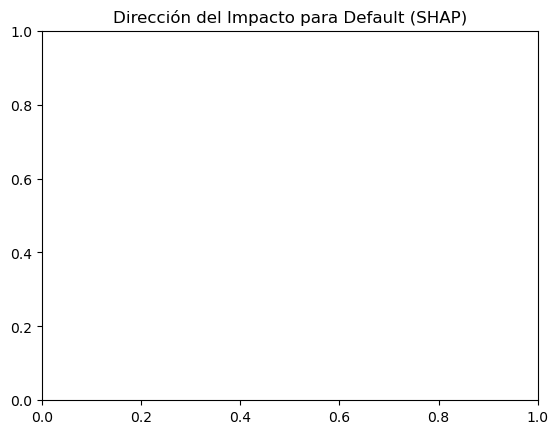

IndexError: index 0 is out of bounds for axis 0 with size 0

In [2]:
# =======================================================
# Ejemplo completo: Credit Scoring Integrado con Riesgo de Seguros usando Stacked Ensemble
# Problema MULTI-TARGET CLASIFICACIÓN: predecir 'default' (1 = incumplimiento crédito) y 'claim' (1 = siniestro seguro)
# Usamos StackingClassifier para ensemble robusto (base: LogisticRegression + RandomForest, meta: XGBoost)
# Dataset sintético profesional con 16 variables (demográficas, financieras, médicas, conductuales)
# Incluye: EDA, entrenamiento, predicciones, análisis de riesgo integrado (bajo/medio/alto con probabilidades combinadas),
# todas las métricas, y análisis de sensibilidad con SHAP (KernelExplainer para stacked model)
# =======================================================
# Requisitos (instala si no los tienes):
# pip install pandas numpy scikit-learn xgboost matplotlib seaborn shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
import shap
from shap import KernelExplainer  # Corregido: Import explícito de KernelExplainer
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Generación de dataset sintético profesional desde cero
# =======================================================
# Simulamos 10,000 clientes con 16 variables realistas para credit scoring + riesgo seguros
# Targets: 'default' (incumplimiento crédito) y 'claim' (siniestro seguro) generados con lógica integrada
np.random.seed(42)
n_samples = 10000

data = {
    # Demográficas/Financieras (para credit scoring)
    'age': np.random.randint(18, 75, n_samples),  # Edad
    'gender': np.random.choice(['Male', 'Female'], n_samples),  # Género
    'income': np.random.normal(60000, 20000, n_samples).clip(20000, 150000).astype(int),  # Ingreso anual
    'debt_to_income_ratio': np.round(np.random.uniform(0.1, 0.6, n_samples), 2),  # Ratio deuda/ingreso
    'credit_score': np.random.normal(700, 100, n_samples).clip(300, 850).astype(int),  # Puntaje crediticio
    'employment_status': np.random.choice(['Employed', 'Unemployed', 'Self-Employed'], n_samples),  # Estatus empleo
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced'], n_samples),  # Estado civil
    'dependents': np.random.randint(0, 5, n_samples),  # Dependientes
    
    # Médicas/Comportamiento (para riesgo seguros)
    'smoker': np.random.choice(['Yes', 'No'], n_samples, p=[0.2, 0.8]),  # Fumador
    'bmi': np.round(np.random.normal(27, 5, n_samples), 1).clip(15, 45),  # BMI
    'blood_pressure_category': np.random.choice(['Normal', 'Elevated', 'High'], n_samples),  # Categoría presión arterial
    'diabetes': np.random.choice(['Yes', 'No'], n_samples, p=[0.15, 0.85]),  # Diabetes
    'heart_disease': np.random.choice(['Yes', 'No'], n_samples, p=[0.1, 0.9]),  # Enfermedad cardíaca
    'exercise_frequency': np.random.choice(['Low', 'Medium', 'High'], n_samples),  # Frecuencia ejercicio
    'alcohol_consumption': np.random.choice(['Low', 'Moderate', 'High'], n_samples),  # Consumo alcohol
    'driving_record': np.random.choice(['Clean', 'Minor Violations', 'Major Violations'], n_samples)  # Registro conducción
}

df = pd.DataFrame(data)

# Generar 'default' con lógica crediticia (alto DTI, bajo credit_score, desempleo aumentan prob)
default_prob = (
    0.05 + 
    0.15 * (df['debt_to_income_ratio'] > 0.4) + 
    0.20 * (df['credit_score'] < 600) + 
    0.10 * (df['employment_status'] == 'Unemployed') + 
    0.08 * (df['dependents'] > 3) + 
    0.05 * (df['age'] < 30)
)
default_prob = default_prob.clip(0, 0.95)
df['default'] = np.random.binomial(1, default_prob)

# Generar 'claim' con lógica de seguros (salud pobre, hábitos riesgosos, conducción mala aumentan prob)
claim_prob = (
    0.10 + 
    0.15 * (df['smoker'] == 'Yes') + 
    0.10 * (df['bmi'] > 30) + 
    0.12 * (df['diabetes'] == 'Yes') + 
    0.18 * (df['heart_disease'] == 'Yes') + 
    0.08 * (df['blood_pressure_category'] == 'High') + 
    0.05 * (df['alcohol_consumption'] == 'High') + 
    0.15 * (df['driving_record'] == 'Major Violations') + 
    0.07 * (df['driving_record'] == 'Minor Violations') + 
    0.05 * (df['age'] > 65)
)
claim_prob = claim_prob.clip(0, 0.95)
df['claim'] = np.random.binomial(1, claim_prob)

print(f"Dataset creado: {df.shape[0]} filas, {df.shape[1]} columnas (16 features + 2 targets)")
print(f"Porcentaje de defaults: {df['default'].mean()*100:.2f}%")
print(f"Porcentaje de claims: {df['claim'].mean()*100:.2f}%")

# =======================================================
# 3. Exploratory Data Analysis (EDA)
# =======================================================
print("\n=== Descripción estadística general ===")
print(df.describe(include='all'))

# Distribución de targets
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='default', data=df, ax=axes[0])
axes[0].set_title('Distribución de Default (0=No, 1=Sí)')
sns.countplot(x='claim', data=df, ax=axes[1])
axes[1].set_title('Distribución de Claim (0=No, 1=Sí)')
plt.tight_layout()
plt.show()

# Correlación numérica
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Variables clave vs targets
fig, axes = plt.subplots(2, 2, figsize=(14,12))
sns.boxplot(x='default', y='credit_score', data=df, ax=axes[0,0])
axes[0,0].set_title('Credit Score vs Default')
sns.boxplot(x='claim', y='bmi', data=df, ax=axes[0,1])
axes[0,1].set_title('BMI vs Claim')
sns.countplot(x='driving_record', hue='claim', data=df, ax=axes[1,0])
axes[1,0].set_title('Driving Record vs Claim')
sns.countplot(x='employment_status', hue='default', data=df, ax=axes[1,1])
axes[1,1].set_title('Employment Status vs Default')
plt.tight_layout()
plt.show()

# =======================================================
# 4. Preprocesamiento
# =======================================================
# Codificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Separar features y targets (multi-target)
X = df.drop(['default', 'claim'], axis=1)
y = df[['default', 'claim']]  # Multi-target

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# =======================================================
# 5. Entrenamiento del modelo Stacked Ensemble (para multi-target, stack por target)
# =======================================================
# Para cada target, creamos un StackingClassifier separado (base: LR + RF, meta: XGB)
def build_stacked_classifier():
    base_estimators = [
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ]
    meta = XGBClassifier(random_state=42)
    return StackingClassifier(estimators=base_estimators, final_estimator=meta, cv=3)

# Modelos para cada target
model_default = build_stacked_classifier()
model_default.fit(X_train, y_train['default'])

model_claim = build_stacked_classifier()
model_claim.fit(X_train, y_train['claim'])

# =======================================================
# 6. Predicciones y probabilidades
# =======================================================
y_pred_default = model_default.predict(X_test)
y_prob_default = model_default.predict_proba(X_test)[:, 1]

y_pred_claim = model_claim.predict(X_test)
y_prob_claim = model_claim.predict_proba(X_test)[:, 1]

# Riesgo integrado: promedio de prob_default y prob_claim
y_prob_integrated = (y_prob_default + y_prob_claim) / 2

# =======================================================
# 7. Clasificación de riesgo integrado (bajo/medio/alto con probabilidades)
# =======================================================
def classify_risk(prob):
    if prob < 0.3:
        return 'Bajo'
    elif prob < 0.7:
        return 'Medio'
    else:
        return 'Alto'

df_test = pd.DataFrame({
    'actual_default': y_test['default'], 'actual_claim': y_test['claim'],
    'prob_default': y_prob_default, 'prob_claim': y_prob_claim,
    'prob_integrated': y_prob_integrated
})
df_test['risk_level'] = df_test['prob_integrated'].apply(classify_risk)

print("\n=== Ejemplos de análisis de riesgo (primeros 10 casos) ===")
print(df_test[['actual_default', 'actual_claim', 'prob_default', 'prob_claim', 'prob_integrated', 'risk_level']].head(10))

print("\nDistribución de niveles de riesgo integrado:")
print(df_test['risk_level'].value_counts(normalize=True) * 100)

# =======================================================
# 8. Métricas de evaluación completas (para cada target + integrado)
# =======================================================
print("\n=== Classification Report para Default ===")
print(classification_report(y_test['default'], y_pred_default))
print(f"AUC-ROC Default: {roc_auc_score(y_test['default'], y_prob_default):.4f}")
print(f"AP Default: {average_precision_score(y_test['default'], y_prob_default):.4f}")

print("\n=== Classification Report para Claim ===")
print(classification_report(y_test['claim'], y_pred_claim))
print(f"AUC-ROC Claim: {roc_auc_score(y_test['claim'], y_prob_claim):.4f}")
print(f"AP Claim: {average_precision_score(y_test['claim'], y_prob_claim):.4f}")

# Métricas integradas (tratando riesgo alto como 1, resto 0)
y_pred_integrated = (y_prob_integrated >= 0.5).astype(int)
print("\n=== Classification Report para Riesgo Integrado (Alto Riesgo vs Resto) ===")
print(classification_report((df_test['actual_default'] | df_test['actual_claim']), y_pred_integrated))
print(f"AUC-ROC Integrado: {roc_auc_score((df_test['actual_default'] | df_test['actual_claim']), y_prob_integrated):.4f}")

# Gráficos: matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_test['default'], y_pred_default), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusión Default')
sns.heatmap(confusion_matrix(y_test['claim'], y_pred_claim), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusión Claim')
plt.tight_layout()
plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(8,6))
fpr_d, tpr_d, _ = roc_curve(y_test['default'], y_prob_default)
ax.plot(fpr_d, tpr_d, label='Default AUC={:.2f}'.format(roc_auc_score(y_test['default'], y_prob_default)))
fpr_c, tpr_c, _ = roc_curve(y_test['claim'], y_prob_claim)
ax.plot(fpr_c, tpr_c, label='Claim AUC={:.2f}'.format(roc_auc_score(y_test['claim'], y_prob_claim)))
ax.plot([0,1], [0,1], 'k--')
ax.legend()
ax.set_title('Curvas ROC')
plt.show()

# =======================================================
# 9. Análisis de sensibilidad con SHAP (KernelExplainer para stacked model - para default como ejemplo)
# =======================================================
# Fondo resumido
background = shap.kmeans(X_train, 100).data

# Función para predecir prob de default (para KernelExplainer)
def predict_default(data):
    return model_default.predict_proba(data)[:, 1]

explainer = KernelExplainer(predict_default, background)

# SHAP values en subconjunto
shap_test_subset = X_test[:100]
shap_values = explainer.shap_values(shap_test_subset)

# Importancia global
shap.summary_plot(shap_values, shap_test_subset, feature_names=X.columns)
plt.title('Importancia Global para Default (SHAP)')
plt.show()

# Dirección del impacto
shap.summary_plot(shap_values, shap_test_subset, plot_type="violin", feature_names=X.columns)
plt.title('Dirección del Impacto para Default (SHAP)')
plt.show()

# Ejemplo individual (caso de alto riesgo integrado)
high_risk_idx = df_test[df_test['risk_level'] == 'Alto'].index[0]
local_idx = np.where(X_test.index == high_risk_idx)[0][0] if hasattr(X_test, 'index') else high_risk_idx
print(f"\nEjemplo individual (alto riesgo integrado): Prob integrada {df_test.loc[high_risk_idx, 'prob_integrated']:.2%}")
shap.force_plot(explainer.expected_value, shap_values[local_idx], 
                shap_test_subset[local_idx], feature_names=X.columns, matplotlib=True)
plt.show()

print("\n¡Análisis completo terminado!")
print("Variables clave: debt_to_income_ratio, credit_score, employment_status para default; driving_record, alcohol_consumption para claim.")
print("Stacked ensemble mejora robustez al combinar modelos base.")
print("Riesgo integrado combina ambos targets para scoring unificado.")
print("SHAP muestra sensibilidad: cómo cada variable afecta las predicciones.")